# Modern Deep Convolutional Neural Networks with PyTorch
## CIFAR-10: Linear Classifier and Multi-Layer Perceptron

This notebook follows the practical lesson in the supplied screenshots. It prepares CIFAR-10, visualizes a mini-batch, trains a linear classifier, then replaces it with a multi-layer perceptron (MLP) and compares test accuracy.

The examples use the screenshot's normalization, Adam learning rate, hidden-layer widths, and five training epochs. A batch size of 128 keeps the exercise practical; the screenshots use a much smaller batch size.

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | device: {device}')

PyTorch 2.13.0 | device: cpu


## 1. Load and inspect CIFAR-10

CIFAR-10 contains 32 x 32 RGB images in 10 classes. Each image is converted to a tensor and normalized with the mean and standard deviation shown in the lesson. The notebook uses a batch size of 128 and `num_workers=0` for practical CPU execution and reliable notebook behavior on macOS.

In [20]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

batch_size = 128
num_workers = 0

data_root = "./data"
trainset = datasets.CIFAR10(
    root=data_root,
    train=True,
    download=True,
    transform=transform,
)
testset = datasets.CIFAR10(
    root=data_root,
    train=False,
    download=True,
    transform=transform,
)

trainloader = DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
)
testloader = DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
)

classes = trainset.classes
print(f"Training images: {len(trainset):,}")
print(f"Test images: {len(testset):,}")
print(f"Classes: {classes}")

Training images: 50,000
Test images: 10,000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### Preview a mini-batch

The displayed images are unnormalized for viewing. Labels are mapped back to their CIFAR-10 class names.

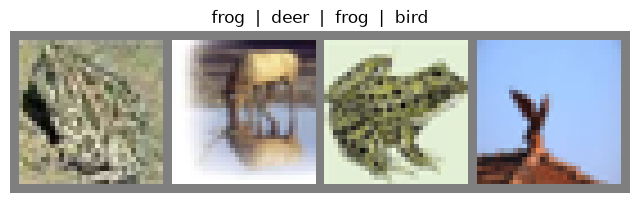

In [21]:
from torchvision.utils import make_grid

images, labels = next(iter(trainloader))
images_to_show = images[:4]
label_names = [classes[label] for label in labels[:4]]

grid = make_grid(images_to_show)
grid = grid * 0.5 + 0.5
plt.figure(figsize=(8, 3))
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.axis("off")
plt.title("  |  ".join(label_names))
plt.show()

## 2. Linear classifier baseline

A linear classifier flattens each `3 x 32 x 32` image into a vector and applies one `nn.Linear` layer to produce 10 class scores. `CrossEntropyLoss` consumes those raw scores (logits), so no softmax is added to the model.

In [22]:
class LinearClassifier(nn.Module):
    def __init__(self, input_neurons, output_neurons):
        super().__init__()
        self.linear = nn.Linear(input_neurons, output_neurons)

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        return self.linear(x)


num_classes = 10
num_input_neurons = 3 * 32 * 32
net = LinearClassifier(num_input_neurons, num_classes).to(device)

sample_images = torch.zeros(2, 3, 32, 32, device=device)
sample_logits = net(sample_images)
assert sample_logits.shape == (2, num_classes)
print(f"Linear classifier output shape: {tuple(sample_logits.shape)}")

Linear classifier output shape: (2, 10)


### Training and evaluation helpers

Training follows the standard PyTorch sequence: clear gradients, run a forward pass, compute cross-entropy loss, backpropagate, then update parameters. Evaluation disables gradient tracking and chooses the class with the largest logit.

In [23]:
def train_model(model, dataloader, criterion, optimizer, epochs=5):
    epoch_losses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        batch_count = 0

        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            batch_count += 1

        average_loss = running_loss / batch_count
        epoch_losses.append(average_loss)
        print(f"Epoch {epoch + 1}/{epochs} - loss: {average_loss:.3f}")

    return epoch_losses


@torch.no_grad()
def evaluate_accuracy(model, dataloader):
    model.eval()
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)
        logits = model(images)
        predictions = logits.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    accuracy = 100 * correct / total
    print(f"Accuracy on {total:,} test images: {accuracy:.1f}%")
    return accuracy

### Train and evaluate the linear baseline

The lecture reports roughly 31% test accuracy for its linear model. Your result can differ with the random initialization, batch size, and runtime.

In [24]:
criterion = nn.CrossEntropyLoss()
linear_optimizer = optim.Adam(net.parameters(), lr=0.001)

In [25]:
linear_losses = train_model(
    net,
    trainloader,
    criterion,
    linear_optimizer,
    epochs=5,
)
print("Finished linear-classifier training")

Epoch 1/5 - loss: 1.842
Epoch 2/5 - loss: 1.767
Epoch 3/5 - loss: 1.744
Epoch 4/5 - loss: 1.730
Epoch 5/5 - loss: 1.723
Finished linear-classifier training


In [26]:
linear_accuracy = evaluate_accuracy(net, testloader)

Accuracy on 10,000 test images: 38.4%


## 3. Multi-layer perceptron

The MLP adds two hidden layers with 256 and 128 units. Leaky ReLU activations make the model nonlinear; the final layer still returns 10 logits for `CrossEntropyLoss`. This is a fully connected model, not yet a convolutional network.

In [27]:
class MLP(nn.Module):
    def __init__(self, input_neurons, output_neurons):
        super().__init__()
        self.main = nn.Sequential(
            nn.Linear(input_neurons, 256),
            nn.LeakyReLU(negative_slope=0.2, inplace=True),
            nn.Linear(256, 128),
            nn.LeakyReLU(negative_slope=0.2, inplace=True),
            nn.Linear(128, output_neurons),
        )

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        return self.main(x)


mlp = MLP(num_input_neurons, num_classes).to(device)
sample_logits = mlp(sample_images)
assert sample_logits.shape == (2, num_classes)
print(f"MLP output shape: {tuple(sample_logits.shape)}")

MLP output shape: (2, 10)


### Train and evaluate the MLP

Run the training cell after the CIFAR-10 loader is ready. The test loader is evaluated without gradients, then predictions are selected with `argmax` over the class scores.

In [28]:
mlp_optimizer = optim.Adam(mlp.parameters(), lr=0.001)

In [29]:
mlp_losses = train_model(
    mlp,
    trainloader,
    criterion,
    mlp_optimizer,
    epochs=5,
)
print("Finished MLP training")

Epoch 1/5 - loss: 1.652
Epoch 2/5 - loss: 1.453
Epoch 3/5 - loss: 1.357
Epoch 4/5 - loss: 1.281
Epoch 5/5 - loss: 1.216
Finished MLP training


In [30]:
mlp_accuracy = evaluate_accuracy(mlp, testloader)

Accuracy on 10,000 test images: 51.5%


## 4. Compare the models

Compare the measured test accuracy and average training loss by epoch. The MLP can learn nonlinear decision boundaries, while the linear classifier is limited to a single linear transformation.

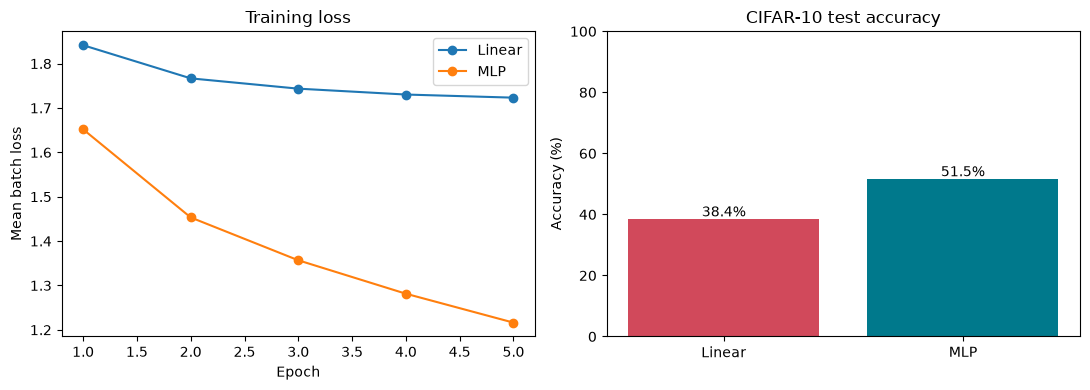

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

epoch_numbers = range(1, len(linear_losses) + 1)
axes[0].plot(epoch_numbers, linear_losses, marker="o", label="Linear")
axes[0].plot(epoch_numbers, mlp_losses, marker="o", label="MLP")
axes[0].set(title="Training loss", xlabel="Epoch", ylabel="Mean batch loss")
axes[0].legend()

bars = axes[1].bar(
    ["Linear", "MLP"],
    [linear_accuracy, mlp_accuracy],
    color=["#d1495b", "#00798c"],
)
axes[1].set(title="CIFAR-10 test accuracy", ylabel="Accuracy (%)", ylim=(0, 100))
for bar in bars:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{bar.get_height():.1f}%",
        ha="center",
    )

plt.tight_layout()
plt.show()

## Takeaway

The linear model and MLP share the same CIFAR-10 data pipeline and optimizer setup. Adding hidden layers and nonlinear activations increases what the classifier can represent, but the MLP still treats the image as a flat vector; convolutional layers are designed to preserve and use spatial structure.